In [3]:
import numpy as np

## 1. Numpy Array vs Python Lists

### 1.1 Speed

In [7]:
# List
import time

a = [i for i in range(10000000)]
b = [i for i in range(10000000, 20000000)]

c = []

start=time.time()
for i in range(len(a)):
    c.append(a[i] + b[i])

end=time.time()
list_time = (end-start)
print(list_time)

2.2181947231292725


In [8]:
# numpy

a = np.arange(10000000)
b = np.arange(10000000,20000000)

start=time.time()
c = a+b
end=time.time()
numpy_time = (end-start)
print(numpy_time)

0.14122509956359863


In [13]:
print(list_time/numpy_time,"time's faster")

15.70680233176498 time's faster


#### 1. Python List

1.  Stores references (memory addresses) to Python objects
2.  Each element is a full Python object
3.  Can store mixed types
4.  Dynamic size, can grow and shrink

##### Mental Model

    list -> [ ref, ref, ref ]

Example:

``` python
lst = [1, 2, 3]
```

Internally: - 1, 2, 3 are separate Python objects
- List stores their references

------------------------------------------------------------------------

#### 2. NumPy Array

1.  Stores raw numeric values directly
2.  Memory is contiguous
3.  All elements must be same dtype
4.  Fixed size after creation

##### Mental Model

    array -> [ 1 | 2 | 3 ]   continuous block

Example:

``` python
import numpy as np
arr = np.array([1, 2, 3])
```

Internally: - Values are stored directly in one continuous memory block

------------------------------------------------------------------------

#### 3. Mutability (NumPy)

1.  Values are mutable

Example:

``` python
arr[0] = 10
```

2.  Size is fixed
    You cannot directly grow it like a list

##### Core Idea

-   Mutable values
-   Fixed size

------------------------------------------------------------------------

#### 4. Adding Element in NumPy

Array is not dynamic.

Correct way:

``` python
arr = np.append(arr, 4)
```

What happens internally:

1.  Creates new memory
2.  Copies old data
3.  Adds new value
4.  Returns new array

------------------------------------------------------------------------

#### 5. Adding Number to Elements

##### arr + 5

``` python
result = arr + 5
```

1.  Creates NEW array
2.  Original array unchanged

##### arr += 5

``` python
arr += 5
```

1.  Modifies SAME array
2.  In-place operation

------------------------------------------------------------------------

#### Final Summary

1.  List stores references and is dynamic in size
2.  NumPy stores raw values and is fixed in size
3.  NumPy values are mutable
4.  arr + 5 creates a new array
5.  arr += 5 modifies the same array


### 1.2 Memory

In [14]:
# List
a = [i for i in range(10000000)]

import sys

sys.getsizeof(a)

89095160

In [19]:
# Numpy

a = np.arange(10000000)

print(sys.getsizeof(a))

a1 = np.arange(10000000, dtype=np.int32)

print(sys.getsizeof(a1))

a2 = np.arange(10000000, dtype=np.int16)

print(sys.getsizeof(a2))

a3 = np.arange(10000000, dtype=np.int8)

print(sys.getsizeof(a3))

80000112
40000112
20000112
10000112


### 1.3 Convenience

List --> convenient for general programming

NumPy --> convenient for heavy mathematical operations

## 2. Advanced Indexing

### 2.1 Normal Indexing and Slicing

In [23]:
a = np.arange(12).reshape(4,3)
print(a)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [26]:
# Indexing
print(a[1,2])

5


In [27]:
# Slicing
print(a[1:3,1:])

[[4 5]
 [7 8]]


### 2.2 Fancy Indexing

In [28]:
print(a)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [29]:
# Fancy Indexing
print(a[[0,2,3]])

[[ 0  1  2]
 [ 6  7  8]
 [ 9 10 11]]


In [31]:
a = np.arange(24).reshape(6,4)
print(a)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [33]:
# Fancy Indexing
print(a[[0,2,3,5]])

[[ 0  1  2  3]
 [ 8  9 10 11]
 [12 13 14 15]
 [20 21 22 23]]


In [34]:
a[:,[0,2,3]]

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

### 2.3 Boolean Indexing

In [6]:
a = np.random.randint(1,100,24).reshape(6,4)
print(a)

[[50 63  9 91]
 [10 99 55 69]
 [43 96 15 11]
 [45 46 54 39]
 [34  7 56 67]
 [54 94 85 43]]


In [27]:
# Find all numbers greater than 50

print(a>50)       # this is a boolean array

a[a>50]           # this is boolean indexing

[[False  True False  True]
 [False  True  True  True]
 [False  True False False]
 [False False  True False]
 [False False  True  True]
 [ True  True  True False]]


array([63, 91, 99, 55, 69, 96, 54, 56, 67, 54, 94, 85], dtype=int32)

In [28]:
# found out even number

print(a%2==0)

a[a%2==0]

[[ True False False False]
 [ True False False False]
 [False  True False False]
 [False  True  True False]
 [ True False  True False]
 [ True  True False False]]


array([50, 10, 96, 46, 54, 34, 56, 54, 94], dtype=int32)

In [29]:
# find all numbers greater than 50 ad are even

print((a>50) & (a%2==0))
# and works only with single boolean values
# & works element-wise for NumPy arrays


a[(a>50) & (a%2==0)]       # This is called Boolean Masking.

[[False False False False]
 [False False False False]
 [False  True False False]
 [False False  True False]
 [False False  True False]
 [ True  True False False]]


array([96, 54, 56, 54, 94], dtype=int32)

For NumPy arrays:

- Use & instead of and

- Use | instead of or

Always wrap each condition inside parentheses

In [33]:
# find all numbers not divisible by 7

print(a%7!=0)

a[a%7!=0]

[[ True False  True False]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True False False  True]
 [ True  True  True  True]]


array([50,  9, 10, 99, 55, 69, 43, 96, 15, 11, 45, 46, 54, 39, 34, 67, 54,
       94, 85, 43], dtype=int32)

In [34]:
a[~(a%7==0)]

array([50,  9, 10, 99, 55, 69, 43, 96, 15, 11, 45, 46, 54, 39, 34, 67, 54,
       94, 85, 43], dtype=int32)

In [35]:
# These do not change the original array. They are just temporary arrays.

## 3. Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is "Brodcast" across the large array so that they have compatible shapes.

In [38]:
# Same Shape

a = np.arange(6).reshape(2,3)
b = np.arange(6,12).reshape(2,3)

print(a)
print()
print(b)
print()
print(a+b)

[[0 1 2]
 [3 4 5]]

[[ 6  7  8]
 [ 9 10 11]]

[[ 6  8 10]
 [12 14 16]]


In [39]:
# Different Shape

a = np.arange(6).reshape(2,3)
b = np.arange(3).reshape(1,3)

print(a)
print()
print(b)
print()
print(a+b)

[[0 1 2]
 [3 4 5]]

[[0 1 2]]

[[0 2 4]
 [3 5 7]]


#### Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>

**2. Make each dimension of the two arrays the same size.**<br>
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

<img src = "https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png">

<img src = "https://blog.paperspace.com/content/images/2020/07/image-17.png " width=500>

<img src = "https://www.practicaldatascience.org/_images/2.3.41-broadcasting_3.png" width=500>

<img src = "https://miro.medium.com/v2/1*f9_LiF9JBlSok0uXzynOFw.png" width=500>

In [45]:
# More examples

a = np.arange(12).reshape(4,3)
b = np.arange(3)

print(a)
print()
print(b)
print()
print(a+b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

[0 1 2]

[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [48]:
a = np.arange(12).reshape(3,4)
b = np.arange(3)

print(a)
print()
print(b)



# print(a+b)    #--> ValueError: operands could not be broadcast together with shapes (3,4) (3,) 


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

[0 1 2]


In [49]:
a = np.arange(3).reshape(1,3)
b = np.arange(3).reshape(3,1)

print(a)
print()
print(b)
print()
print(a+b)

[[0 1 2]]

[[0]
 [1]
 [2]]

[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [50]:
a = np.arange(3).reshape(1,3)
b = np.arange(4).reshape(4,1)

print(a)
print()
print(b)
print()
print(a+b)

[[0 1 2]]

[[0]
 [1]
 [2]
 [3]]

[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [51]:
a = np.arange(3).reshape(1,3)
b = np.arange(4).reshape(4,1)

a_expanded = np.broadcast_to(a, (4,3))
b_expanded = np.broadcast_to(b, (4,3))

print("Broadcasted a:")
print(a_expanded)

print("\nBroadcasted b:")
print(b_expanded)

Broadcasted a:
[[0 1 2]
 [0 1 2]
 [0 1 2]
 [0 1 2]]

Broadcasted b:
[[0 0 0]
 [1 1 1]
 [2 2 2]
 [3 3 3]]


In [52]:
a = np.array([1])
# shape--> (1,1)

b = np.arange(4).reshape(2,2)
# shape--> (2,2)

print(a)
print()
print(b)
print()
print(a+b)

[1]

[[0 1]
 [2 3]]

[[1 2]
 [3 4]]


In [55]:
a = np.arange(12).reshape(3,4)
b = np.arange(12).reshape(4,3)


print(a)
print()
print(b)


# print(a+b)     #--> ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [59]:
a = np.arange(16).reshape(4,4)
b = np.arange(4).reshape(2,2)


print(a)
print()
print(b)


# print(a+b)     #--> ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

[[0 1]
 [2 3]]


## 4. Working with mathematical formulas

In [3]:
a = np.arange(10)
np.sum(a)

np.int64(45)

The sigmoid function is:

σ(x) = 1 / (1 + e^(-x))

It converts **any real number** into a value between **0 and 1**.

It is heavily used in:

1. Logistic Regression  
2. Binary Classification  
3. Neural Networks  

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/0*D5do3xhv5ulF50w2.png" width=600>

In [8]:
# sigmoid

def sigmoid(array):
    return 1/(1+np.exp(-(array)))
 
 
a = np.arange(100)

sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661,
       0.9999546 , 0.9999833 , 0.99999386, 0.99999774, 0.99999917,
       0.99999969, 0.99999989, 0.99999996, 0.99999998, 0.99999999,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [4]:
# mean squared error

actual = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)

In [5]:
print(actual)
print(predicted)

[24 29 31 28  5  9 11 44 40  2 16 36 41  8 21  9 22 19 14 39 26 10 20 40
 45]
[ 3 30 15  9 39 42 15 14 49 12 11 23 35 42 25 16  9 43 12 43 15 27 34 39
  7]


In [10]:
def mse(actual,predicted):
    return np.mean((actual - predicted)**2)
    

result = mse(actual,predicted)
print(result)

346.72


In [11]:
# binaray cross entropy


def binary_cross_entropy(y_true, y_pred):
    # Avoid log(0) error
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(
        y_true * np.log(y_pred) + 
        (1 - y_true) * np.log(1 - y_pred)
    )
    
    return loss


# Example usage
y_true = np.array([1, 0, 1, 1, 0])
y_pred = np.array([0.9, 0.2, 0.8, 0.7, 0.1])

loss = binary_cross_entropy(y_true, y_pred)
print(loss)

0.20273661557656092


## 5. Working with missing values

In [14]:
a = np.array([1,2,3,4,np.nan,6])
a

# In numpy nan is missing values. none and nan are different

array([ 1.,  2.,  3.,  4., nan,  6.])

In [19]:
np.isnan(a)

array([False, False, False, False,  True, False])

In [20]:
a[np.isnan(a)]

array([nan])

In [21]:
a[~np.isnan(a)]

array([1., 2., 3., 4., 6.])

### Missing Values in NumPy: `np.nan` vs `None`

```python
import numpy as np

a = np.array([1, 2, 3, 4, np.nan, 6])
a
```

In NumPy:
- `np.nan` represents missing numeric data.
- `None` and `np.nan` are different.

---

### 1. What is `np.nan`?

`np.nan` means **Not a Number**.

It is a special floating-point value defined by the IEEE standard.

### Important Properties

```python
import numpy as np

x = np.nan

print(x == x)        # False
print(np.isnan(x))   # True
```

`np.nan` is NOT equal to itself.

---

### 2. What is `None`?

`None` is a Python object that represents absence of value.

```python
x = None
print(x == None)  # True
```

But:

- `None` is not numeric.
- `np.nan` is numeric (float).

---

### 3. What Happens in the Array?

```python
a = np.array([1, 2, 3, 4, np.nan, 6])
print(a)
print(a.dtype)
```

Output dtype:

```
float64
```

Why?

- NumPy arrays must have a single data type.
- `np.nan` is a float.
- So NumPy converts all integers to float.

Internally it becomes:

```
[1. 2. 3. 4. nan 6.]
```

---

### 4. If You Use `None` Instead

```python
a = np.array([1, 2, 3, 4, None, 6])
print(a.dtype)
```

Output dtype:

```
object
```

Object dtype is slower and not ideal for ML.

---

### 5. Why We Use `np.nan` in ML

1. NumPy provides built-in functions:
   - `np.isnan()`
   - `np.nanmean()`
   - `np.nanstd()`

2. ML libraries expect numeric arrays.

3. Mathematical operations can ignore NaN using special functions.

Example:

```python
np.mean(a)        # Returns nan
np.nanmean(a)     # Ignores nan
```

---

### Important Concept

`np.nan != np.nan`

This happens because NaN represents an undefined numeric value.

## 6. Plotting Graph

In [25]:
# plotting a 2D plot
# x = y

x = np.linspace(-10,10,100)
print(x)
print()

y = x
print(y)

[-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   5.151515

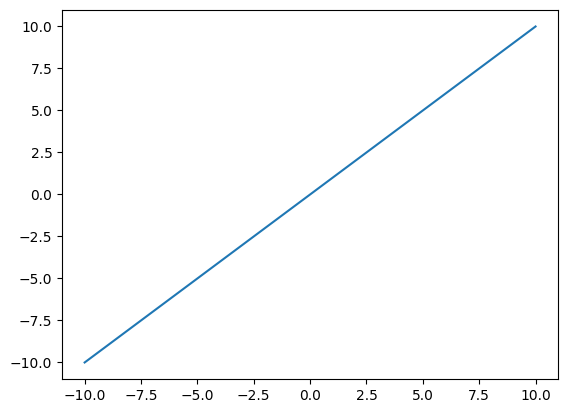

In [27]:
import matplotlib.pyplot as plt

plt.plot(x,y)

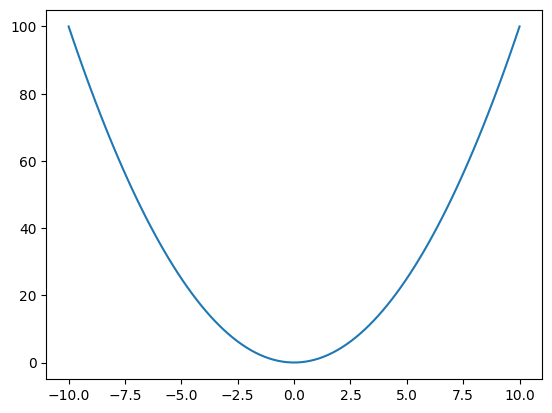

In [30]:
# y=x^2

x = np.linspace(-10,10,100)
y = x**2

plt.plot(x,y)

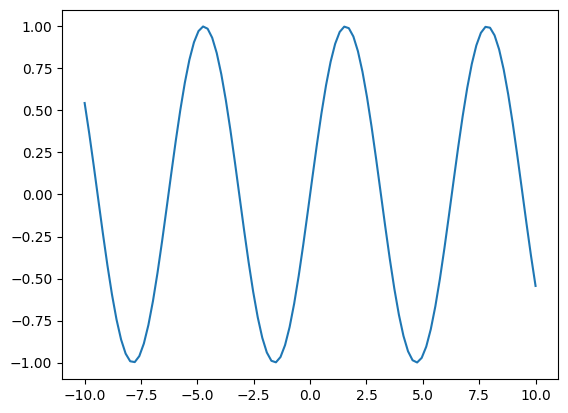

In [31]:
# y = sin(x)

x = np.linspace(-10,10,100)
y = np.sin(x)

plt.plot(x,y)

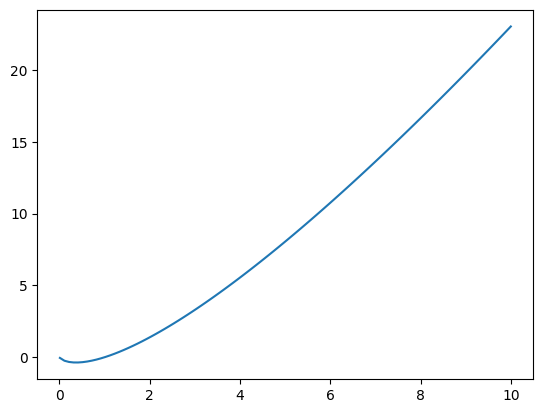

In [35]:
# y = xlog(x)

x = np.linspace(0.01, 10, 100)   # start from positive value
y = x * np.log(x)

plt.plot(x, y)

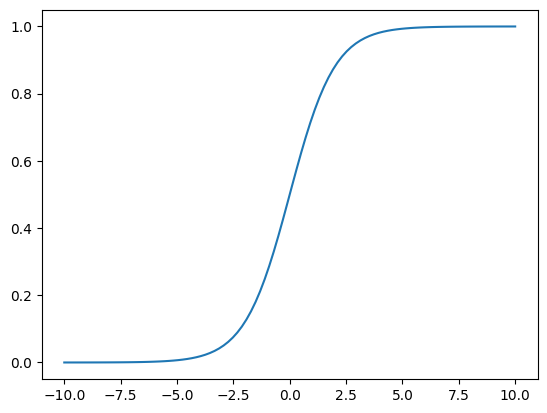

In [37]:
# sigmoid graph

x = np.linspace(-10,10,100)
y = 1/(1+np.exp(-x))

plt.plot(x,y)